# M1M9-GARCH: original M6 vs locally scaled M6

Ten paired Monte Carlo seeds (2020-2029). The data, M6 point model, OOT calibration and alpha are unchanged; only residual calibration is locally standardized. No support constraint is applied.

In [1]:
from pathlib import Path
import sys, matplotlib.pyplot as plt, numpy as np, pandas as pd
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src').exists()),None); sys.path.insert(0,str(ROOT/'src'))
from kf_forecasting.models.kf_enbpi import EnbPIConfig,simulate_m1_m9_garch_low_constant_high_variance_data
from kf_forecasting.models.kf_out_of_time_enbpi import OutOfTimeEnbPIConfig,locally_scaled_from_fitted,run_out_of_time_enbpi
SEEDS=range(2020,2030); TRAIN=650; HORIZON=200; ALPHA=.05; K=60

In [2]:
def metric(y,p,l,u):
 ml=y<l; mu=y>u
 return {'coverage':np.mean((y>=l)&(y<=u)),'mean_width':np.mean(u-l),'median_width':np.median(u-l),'interval_score':np.mean(u-l+2/ALPHA*((l-y)*ml+(y-u)*mu)),'rmse':np.sqrt(np.mean((y-p)**2)),'mae':np.mean(abs(y-p)),'negative_lower_rate':np.mean(l<0)}
rows=[]; frames=[]
for seed in SEEDS:
 _,_,y=simulate_m1_m9_garch_low_constant_high_variance_data(TRAIN+HORIZON,rng=np.random.default_rng(seed))
 fit=run_out_of_time_enbpi(y,TRAIN,config=OutOfTimeEnbPIConfig(base=EnbPIConfig(alpha=ALPHA,random_state=seed)),model_name='M1M9 original M6',data_seed=seed)
 scaled=locally_scaled_from_fitted(fit,pd.Index(fit.forecast.test_times),neighbours=K,support_lower=None); f=fit.forecast
 variants=[('Original M6',fit.selected_residual_window,f.truth,f.point,f.lower,f.upper),('Local-scale M6',scaled.selected_window,*[scaled.predictions[c].to_numpy() for c in ['truth','point','lower','upper']])]
 for method,w,truth,point,lower,upper in variants:
  rows.append({'seed':seed,'method':method,'selected_window':'all' if w is None else w,**metric(truth,point,lower,upper)})
  frames.append(pd.DataFrame({'seed':seed,'time':f.test_times,'method':method,'truth':truth,'point':point,'lower':lower,'upper':upper}))
 print('finished seed',seed)
metrics_by_seed=pd.DataFrame(rows); predictions=pd.concat(frames,ignore_index=True)

finished seed 2020
finished seed 2021
finished seed 2022
finished seed 2023
finished seed 2024
finished seed 2025
finished seed 2026
finished seed 2027
finished seed 2028
finished seed 2029


In [3]:
cols=['rmse','mae','coverage','mean_width','median_width','interval_score','negative_lower_rate']
summary=metrics_by_seed.groupby('method')[cols].agg(['mean','std']); summary

rmse                 mae           coverage            \
                    mean       std      mean       std     mean       std   
method                                                                      
Local-scale M6  3.395201  0.623680  2.668631  0.451731    0.926  0.016799   
Original M6     3.392837  0.630312  2.666036  0.450144    0.922  0.031815   

               mean_width           median_width           interval_score  \
                     mean       std         mean       std           mean   
method                                                                      
Local-scale M6  12.697979  2.082702    12.210158  2.042821      16.896377   
Original M6     12.378223  1.392267    12.292013  1.457755      17.643629   

                         negative_lower_rate           
                     std                mean      std  
method                                                 
Local-scale M6  3.240517               1.000  0.00000  
Original M6     4.332856               0.997  0.00483

In [4]:
pd.crosstab(metrics_by_seed.method,metrics_by_seed.selected_window)

selected_window,100,120,180,200,300,400,all
method,,,,,,,
Local-scale M6,0,1,5,0,2,0,2
Original M6,2,0,0,3,4,1,0


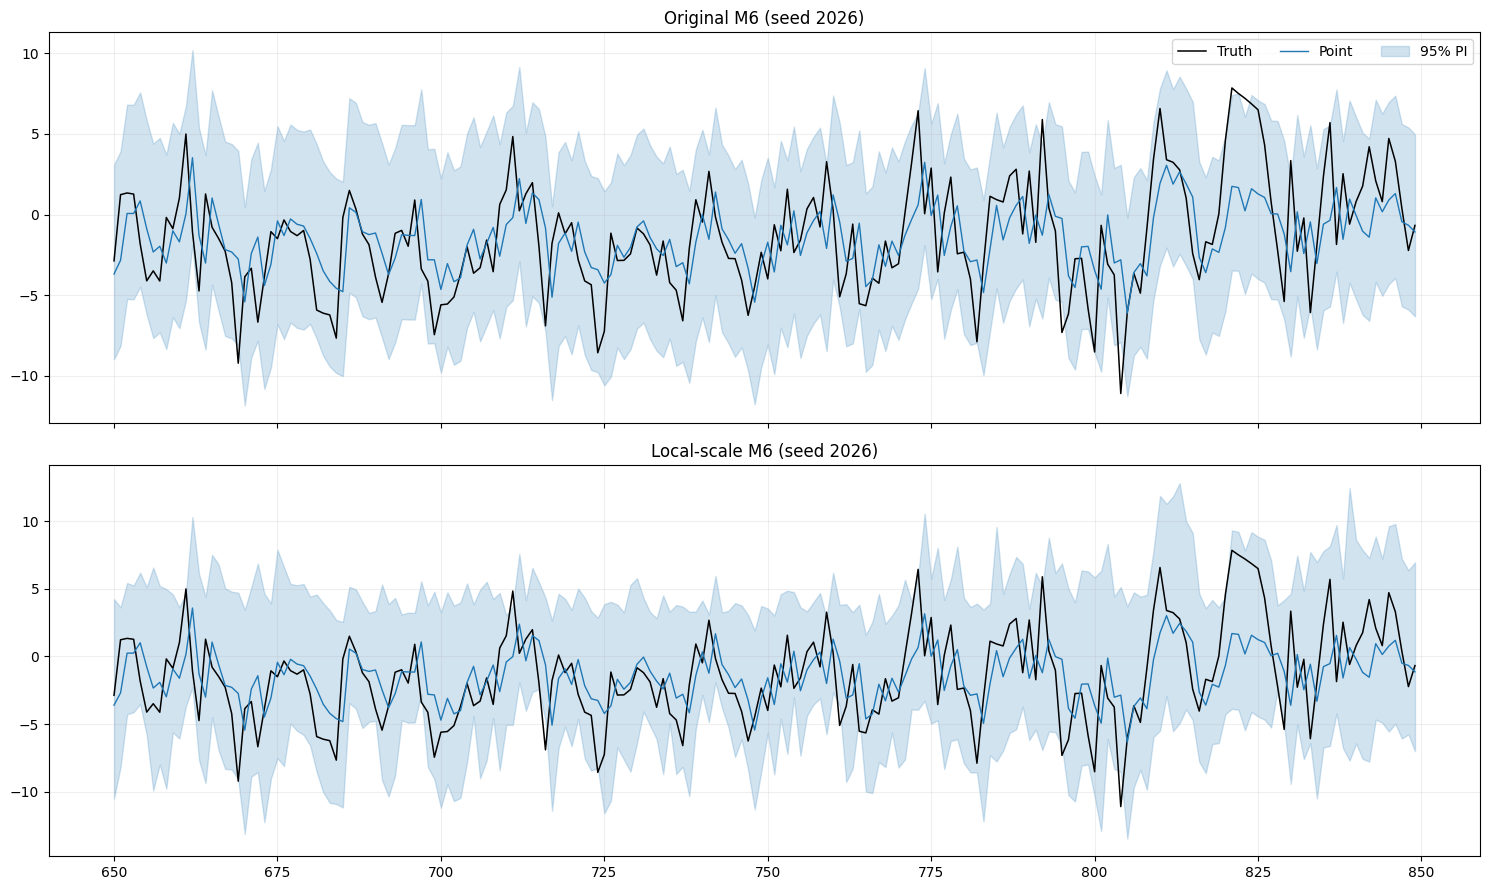

In [5]:
g=predictions[predictions.seed==2026]; fig,axes=plt.subplots(2,1,figsize=(15,9),sharex=True)
for ax,(m,d) in zip(axes,g.groupby('method',sort=False)):
 ax.plot(d.time,d.truth,'k',lw=1.1,label='Truth'); ax.plot(d.time,d.point,color='tab:blue',lw=1,label='Point'); ax.fill_between(d.time,d.lower,d.upper,color='tab:blue',alpha=.2,label='95% PI'); ax.set_title(f'{m} (seed 2026)'); ax.grid(alpha=.2)
axes[0].legend(ncol=3); fig.tight_layout(); plt.show()